# Importing functions and utilities

In [1]:
# Importing required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import joblib # for saving the parameter of linear regression model
from pathlib import Path

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from tqdm.notebook import tqdm
from tqdm import tqdm 


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Importing functions from mypackage
from mypackage_utils import *

# Importing dataset of sp500
sp500  = joblib.load("sp500_updated.pkl")
sp500_weights = Path("S&P500")

In [2]:
def train_sp500_fd(weight_filename, train_set, val_set, test_set, target_train, target_val, target_test):
    # Transforming data into tensor 
    train_set = torch.tensor(train_set, dtype=torch.float32)
    val_set = torch.tensor(val_set, dtype=torch.float32)
    test_set = torch.tensor(test_set, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)
    
    # Define the MLP model
    nhidden = 32
    model = nn.Sequential(nn.Linear(4, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, 1))
    # Dataset e DataLoader
    train_dataset = TensorDataset(train_set, target_train)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer 
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 1000
    # Training loop
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_set)
            val_loss = criterion(val_outputs, target_val).item()

        # Store train and validation loss
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log') 
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_set).detach().numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    return [test_loss, test_rmse, test_mae, predictions]
	
def train_sp500_d(weight_filename, train_set, val_set, test_set, target_train, target_val, target_test):
    # Transforming data into tensor 
    train_set = torch.tensor(train_set, dtype=torch.float32)
    val_set = torch.tensor(val_set, dtype=torch.float32)
    test_set = torch.tensor(test_set, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)
    
    # Define the MLP model
    nhidden = 32
    model = nn.Sequential(nn.Linear(4, nhidden),
                                nn.ReLU(),
                                nn.Linear(nhidden, nhidden),
                                nn.ReLU(),
                                nn.Linear(nhidden, 1))
    # Dataset e DataLoader
    train_dataset = TensorDataset(train_set, target_train)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer 
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 700
    # Training loop
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_set)
            val_loss = criterion(val_outputs, target_val).item()

        # Store train and validation loss
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log') 
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_set).detach().numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    return [test_loss, test_rmse, test_mae, predictions]
	
def train_sp500_fd_sw(weight_filename, train_set_fd, val_set_fd_sw, test_set_fd_sw, target_train_fd_sw, target_val_fd_sw, target_test_fd_sw):	
	# Transforming data into tensor 
	train_set_fd= torch.tensor(train_set_fd_sw, dtype=torch.float32)
	val_set_fd = torch.tensor(val_set_fd_sw, dtype=torch.float32)
	test_set_fd = torch.tensor(test_set_fd_sw, dtype=torch.float32)
	target_train_fd = torch.tensor(target_train_fd_sw, dtype=torch.float32).view(-1, 1)
	target_val_fd = torch.tensor(target_val_fd_sw, dtype=torch.float32).view(-1, 1)
	target_test_fd = torch.tensor(target_test_fd_sw, dtype=torch.float32).view(-1, 1)

	# Define the MLP model
	nhidden = 64
	model = nn.Sequential(nn.Linear(20, nhidden),
							nn.ReLU(),
							nn.Linear(nhidden,nhidden),
							nn.ReLU(),
							nn.Linear(nhidden, 1))
	# Dataset e DataLoader
	train_dataset_fd_sw = TensorDataset(train_set_fd, target_train_fd)
	train_loader = DataLoader(train_dataset_fd_sw, batch_size=len(train_set_fd_sw), shuffle=False) # Shuffle False because of time series data

	# Defining loss, optimizer 
	criterion = nn.MSELoss()
	optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)


	n_epochs = 1000
	# Training loop
	train_curve, val_curve = [], []
	training_loop = tqdm(range(n_epochs)) 
	for epoch in training_loop:
		# Training mode
		model.train() 
		running = 0.0 
		for batch_data, batch_targets in train_loader:
			# Reset computation graph
			optimizer.zero_grad()
			# Forward pass
			outputs = model(batch_data)
			# Compute training loss on batch
			loss = criterion(outputs, batch_targets)
			# Compute gradient 
			loss.backward()
			# Gradient step
			optimizer.step()
			# Loss per batch 
			running += loss.item()
		# Loss per epoch
		train_epoch = running / len(train_loader)

		# Validation loss
		model.eval()
		with torch.no_grad():
			val_outputs = model(val_set_fd).detach()
			val_loss = criterion(val_outputs, target_val_fd).item()

		# Store train and validation loss
		train_curve.append(train_epoch)
		val_curve.append(val_loss)

		# Print loss in the progression bar
		training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

	# Save the final model weights
	torch.save(model.state_dict(), weight_filename)
	# Plot losses
	plt.figure()
	plt.plot(train_curve, label='train')
	plt.plot(val_curve,   label='val')
	plt.yscale('log') 
	plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
	plt.show()			

	# Metrics evaluation 
	model.load_state_dict(torch.load(weight_filename)) 
	model.eval()
	with torch.no_grad():
		predictions = model(test_set_fd).detach().numpy() 
		test_loss = mean_squared_error(target_test_fd.numpy(), predictions)
		test_rmse = np.sqrt(test_loss)
		test_mae = mean_absolute_error(target_test_fd.numpy(), predictions)
	return [test_loss, test_rmse, test_mae, predictions]

def train_sp500_d_sw(weight_filename, train_set_d_sw, val_set_d_sw, test_set_d_sw, target_train_d_sw, target_val_d_sw, target_test_d_sw):
	# Transforming data into tensor 
	train_set_d= torch.tensor(train_set_d_sw, dtype=torch.float32)
	val_set_d = torch.tensor(val_set_d_sw, dtype=torch.float32)
	test_set_d = torch.tensor(test_set_d_sw, dtype=torch.float32)
	target_train_d = torch.tensor(target_train_d_sw, dtype=torch.float32).view(-1, 1)
	target_val_d = torch.tensor(target_val_d_sw, dtype=torch.float32).view(-1, 1)
	target_test_d = torch.tensor(target_test_d_sw, dtype=torch.float32).view(-1, 1)

	# Define the MLP model
	nhidden = 64
	model = nn.Sequential(nn.Linear(20, nhidden),
							nn.ReLU(),
							nn.Linear(nhidden,nhidden),
							nn.ReLU(),
							nn.Linear(nhidden, 1))
	# Dataset e DataLoader
	train_dataset_d_sw = TensorDataset(train_set_d, target_train_d)
	train_loader = DataLoader(train_dataset_d_sw, batch_size=512, shuffle=False) # Shuffle False because of time series data

	# Defining loss, optimizer 
	criterion = nn.MSELoss()
	optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

	n_epochs = 500
	# Training loop
	train_curve, val_curve = [], []
	training_loop = tqdm(range(n_epochs)) 
	for epoch in training_loop:
		# Training mode
		model.train() 
		running = 0.0 
		for batch_data, batch_targets in train_loader:
			# Reset computation graph
			optimizer.zero_grad()
			# Forward pass
			outputs = model(batch_data)
			# Compute training loss on batch
			loss = criterion(outputs, batch_targets)
			# Compute gradient 
			loss.backward()
			# Gradient step
			optimizer.step()
			# Loss per batch 
			running += loss.item()
		# Loss per epoch
		train_epoch = running / len(train_loader)

		# Validation loss
		model.eval()
		with torch.no_grad():
			val_outputs = model(val_set_d).detach()
			val_loss = criterion(val_outputs, target_val_d).item()

		# Store train and validation loss
		train_curve.append(train_epoch)
		val_curve.append(val_loss)

		# Print loss in the progression bar
		training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

	# Save the final model weights
	torch.save(model.state_dict(), weight_filename)
	# Plot losses
	plt.figure()
	plt.plot(train_curve, label='train')
	plt.plot(val_curve,   label='val')
	plt.yscale('log') 
	plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
	plt.show()			

	# Metrics evaluation 
	model.load_state_dict(torch.load(weight_filename)) 
	model.eval()
	with torch.no_grad():
		predictions = model(test_set_d).detach().numpy() 
		test_loss = mean_squared_error(target_test_d.numpy(), predictions)
		test_rmse = np.sqrt(test_loss)
		test_mae = mean_absolute_error(target_test_d.numpy(), predictions)
	return [test_loss, test_rmse, test_mae, predictions]


def simulate_trading_sp500(predictions):
    # If instead of predicting the log-close, I predict the log-return
    # Initialize daily profit/loss (PnL)
    daily_pnl = []
    actual_price = sp500['Close'].iloc[-len(predictions)-1:].values.astype(float)
    # If predictions[i] > 0 => P_t+1 > P_t  => long position
    # Simulate trading logic
    for i in range(len(predictions)):
        # Today's price and tomorrow's actual price
        today_price = actual_price[i]
        tomorrow_price = actual_price[i + 1]
        
        # Trading decision: long (1) or short (-1)
        position = 1 if predictions[i] > 0 else -1
        
        # Calculate profit/loss for the day
        pnl = position * (tomorrow_price - today_price)
        daily_pnl.append(pnl)
    # Calculate cumulative profit/loss
    cumulative_pnl = np.cumsum(daily_pnl)
    return cumulative_pnl

# Training 

In this notebook we investigate different forecasting strategies for the **S&P 500** time series. Our objective is to understand how the **training loss** and overall learning behaviour respond to different preprocessing choices and model configurations.

We consider two forms of data transformation: **integer differentiation** and **fractional differentiation**. For each of these preprocessed series, we train models under two forecasting setups — **one-step-ahead prediction** and the **sliding-window approach** — allowing us to compare their performance across both the data transformations and the forecasting schemes.

The goal of the notebook is to determine, for each combination of preprocessing and forecasting method, the most suitable neural architecture and set of hyperparameters.

In [3]:
d_cols = ['Close_d', 'Open_d', 'High_d', 'Low_d']
fd_cols = ['Close_fd', 'Open_fd', 'High_fd', 'Low_fd']
train_set_fd, val_set_fd, test_set_fd, target_train_fd, target_val_fd, target_test_fd = prepare_data(sp500, fd_cols)
train_set_d, val_set_d, test_set_d, target_train_d, target_val_d, target_test_d = prepare_data(sp500, d_cols)
train_set_fd_sw, val_set_fd_sw, test_set_fd_sw, target_train_fd_sw, target_val_fd_sw, target_test_fd_sw = prepare_data_sw(sp500, fd_cols, window_size=5)
train_set_d_sw, val_set_d_sw, test_set_d_sw, target_train_d_sw, target_val_d_sw, target_test_d_sw = prepare_data_sw(sp500, d_cols, window_size=5)

100%|██████████| 1000/1000 [00:04<00:00, 214.56it/s, lr=0.001, train=8.99e-5, val=7.91e-5] 


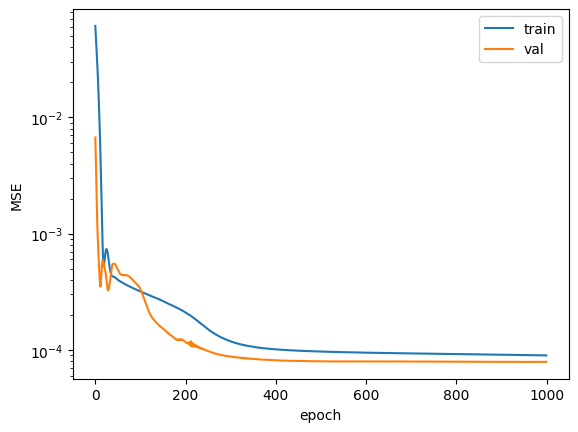

100%|██████████| 700/700 [00:03<00:00, 177.99it/s, lr=0.001, train=8.52e-5, val=7.5e-5]  


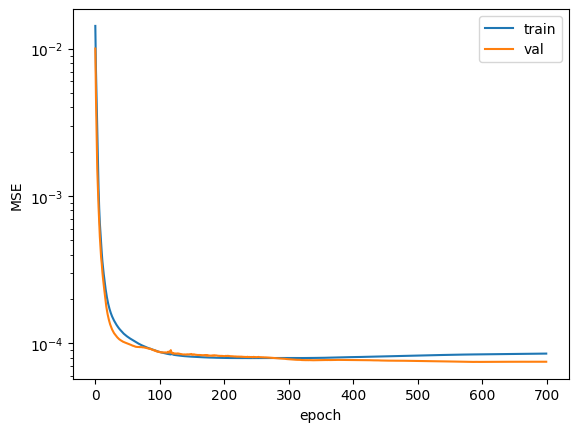

100%|██████████| 1000/1000 [00:05<00:00, 168.45it/s, lr=0.01, train=8.52e-5, val=7.76e-5]


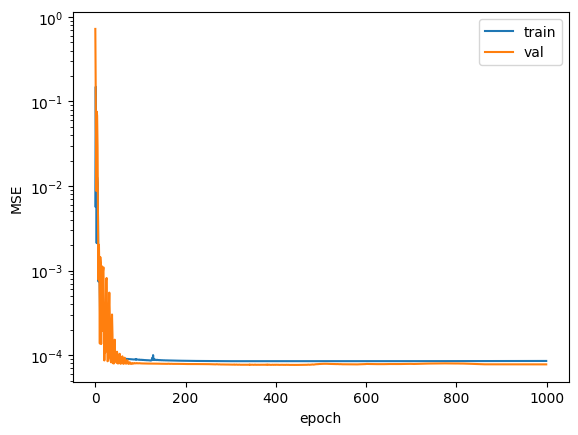

100%|██████████| 500/500 [00:02<00:00, 189.48it/s, lr=0.001, train=7.86e-5, val=7.43e-5] 


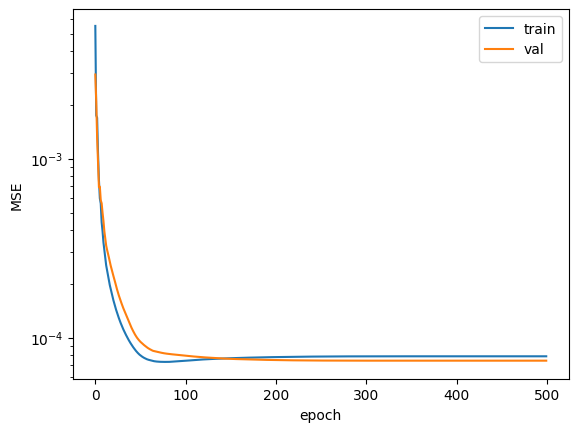

In [4]:
# Training with one-step ahead approach
results_fd = train_sp500_fd( sp500_weights / 'sp500_mlp_fd_weights.pth', train_set_fd, val_set_fd, test_set_fd, target_train_fd, target_val_fd, target_test_fd)
results_d = train_sp500_d(sp500_weights / 'sp500_mlp_d_weights.pth', train_set_d, val_set_d, test_set_d, target_train_d, target_val_d, target_test_d)
# Training with sliding window approach
results_fd_sw = train_sp500_fd_sw(sp500_weights / 'sp500_mlp_fd_sw_weights.pth', train_set_fd_sw, val_set_fd_sw, test_set_fd_sw, target_train_fd_sw, target_val_fd_sw, target_test_fd_sw)
results_d_sw = train_sp500_d_sw(sp500_weights / 'sp500_mlp_d_sw_weights.pth', train_set_d_sw, val_set_d_sw, test_set_d_sw, target_train_d_sw, target_val_d_sw, target_test_d_sw)


In [5]:
# Improvement of using fractional differetiation instead of integer differentiation
print("Results with fractional differentiation:")
print(f"Test MSE: {results_fd[0]:.6f}, Test RMSE: {results_fd[1]:.6f}, Test MAE: {results_fd[2]:.6f}")
print("Results with integer differentiation:")
print(f"Test MSE: {results_d[0]:.6f}, Test RMSE: {results_d[1]:.6f}, Test MAE: {results_d[2]:.6f}")
print("Results with fractional differentiation and sliding window:")
print(f"Test MSE: {results_fd_sw[0]:.6f}, Test RMSE: {results_fd_sw[1]:.6f}, Test MAE: {results_fd_sw[2]:.6f}")
print("Results with integer differentiation and sliding window:")
print(f"Test MSE: {results_d_sw[0]:.6f}, Test RMSE: {results_d_sw[1]:.6f}, Test MAE: {results_d_sw[2]:.6f}")

Results with fractional differentiation:
Test MSE: 0.000307, Test RMSE: 0.017522, Test MAE: 0.010825
Results with integer differentiation:
Test MSE: 0.000322, Test RMSE: 0.017939, Test MAE: 0.010085
Results with fractional differentiation and sliding window:
Test MSE: 0.000327, Test RMSE: 0.018071, Test MAE: 0.010067
Results with integer differentiation and sliding window:
Test MSE: 0.000328, Test RMSE: 0.018108, Test MAE: 0.010153


In [6]:
# Take the path of the folder to save the weights into that directory
weights_dir = Path("weights")
# Comparing NN with Linear Regression
results_lr_fd  = trading_signal_strategy(sp500, test_set_fd,  weights_dir / "lin_reg_sp500_fd.pkl",  mode="fractional", n_features=4, model="linear_regression")
results_lr_d   = trading_signal_strategy(sp500, test_set_d,   weights_dir / "lin_reg_sp500_d.pkl",   mode="integer",    n_features=4, model="linear_regression")
results_lr_fd_sw = trading_signal_strategy(sp500, test_set_fd_sw, weights_dir / "lin_reg_sp500_fd_sw.pkl",  mode="sliding_window", n_features=5 * 4, model="linear_regression")
results_lr_d_sw   = trading_signal_strategy(sp500, test_set_d_sw,  weights_dir / "lin_reg_sp500_d_sw.pkl",   mode="sliding_window",    n_features=5 * 4, model="linear_regression")

# Trading performance

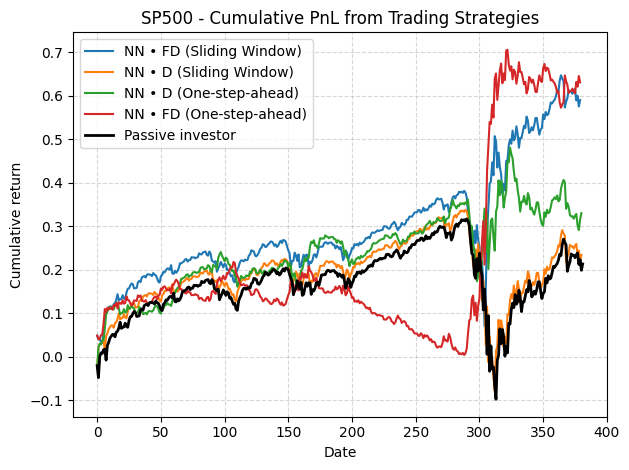

In [7]:
# Simulate trading strategies
cumulative_pnl_d = simulate_trading_sp500(results_d[-1])
cumulative_pnl_fd = simulate_trading_sp500(results_fd[-1])
# Simulate trading strategy with sliding window
cumulative_pnl_fd_sw = simulate_trading_sp500(results_fd_sw[-1])
cumulative_pnl_d_sw = simulate_trading_sp500(results_d_sw[-1])
# NN with fractionally differentiated data and sliding window
plt.plot(cumulative_pnl_fd_sw, label='NN • FD (Sliding Window)')
# NN with differentiated data and sliding window
plt.plot(cumulative_pnl_d_sw, label='NN • D (Sliding Window)')
# NN with differentiated data
plt.plot(cumulative_pnl_d, label='NN • D (One-step-ahead)')
# NN with fractionally differentiated data
plt.plot(cumulative_pnl_fd, label='NN • FD (One-step-ahead)')

# Linear regression plots (uncomment to visualize)
#plt.plot(results_lr_fd, label='Linear Regression • FD', linestyle="--", color="red")
#plt.plot(results_lr_d, label='Linear Regression • D', linestyle="--", color="red")
#plt.plot(results_lr_fd_sw, label='Linear Regression • FD (Sliding Window)', linestyle="--", color="red")
#plt.plot(results_lr_d_sw, label='Linear Regression • D (Sliding Window)', linestyle="--", color="red")


# Passive investor	
plt.plot(sp500['Close_d'].iloc[-len(test_set_d)-1:].to_numpy().cumsum(), label="Passive investor", color="black", linestyle="-", linewidth=2)
plt.title(f"SP500 - Cumulative PnL from Trading Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best")
plt.tight_layout()
plt.show()